In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("state_averages.csv")
df_encoded = df.drop(columns=["state"])
print(df.head())

  state  case_id   isMetro  housing_cost    food_cost  transportation_cost  \
0    AK     82.0  0.103448  15520.427586  8694.782041         12361.720750   
1    AL     34.0  0.432836   9181.392518  8480.711293         13141.568890   
2    AR    149.0  0.266667   8886.487749  7788.489356         13131.927386   
3    AZ    104.0  0.533333  12793.910734  8146.288516         13479.581414   
4    CA    215.5  0.637931  20232.487360  9673.952906         14740.170922   

   healthcare_cost  other_necessities_cost  childcare_cost         taxes  \
0     15641.815574             8774.125398    15194.391719   9047.294052   
1     14236.294295             6399.676771     9552.574830   7975.351473   
2     12038.511863             6042.001845     7732.104276   5872.369266   
3     14532.482911             7587.459998    11314.893078   8131.322522   
4     14221.493600            10836.282740    10761.334636  12713.440853   

     total_cost  median_family_income  
0  85234.557360          81242.831

In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

#Total Cost
X = df_encoded.drop(columns=["total_cost"])  # features
y = df_encoded["total_cost"]                 # target variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred)) 
print("R2:", r2_score(y_test, y_pred))

MSE: 5119881.559682182
R2: 0.9340830015409102


In [6]:
import pandas as pd
# Find which values are most important 
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

housing_cost              0.520374
taxes                     0.273824
childcare_cost            0.062275
other_necessities_cost    0.061756
median_family_income      0.025620
food_cost                 0.020517
transportation_cost       0.016111
healthcare_cost           0.012036
case_id                   0.004575
isMetro                   0.002913
dtype: float64


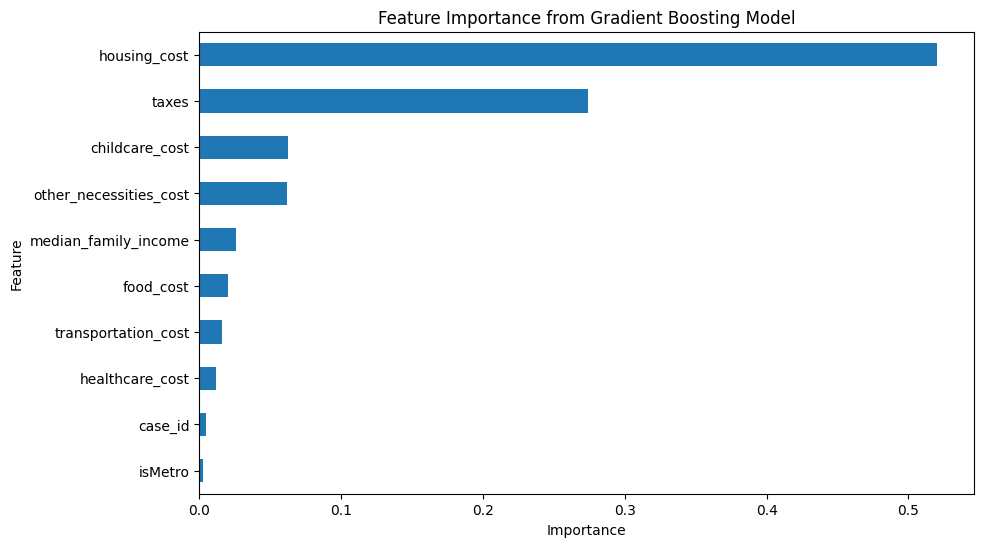

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)

# Sort features
importance = importance.sort_values(ascending=True)

# Plot
plt.figure(figsize=(10,6))
importance.plot(kind='barh')
plt.title("Feature Importance from Gradient Boosting Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

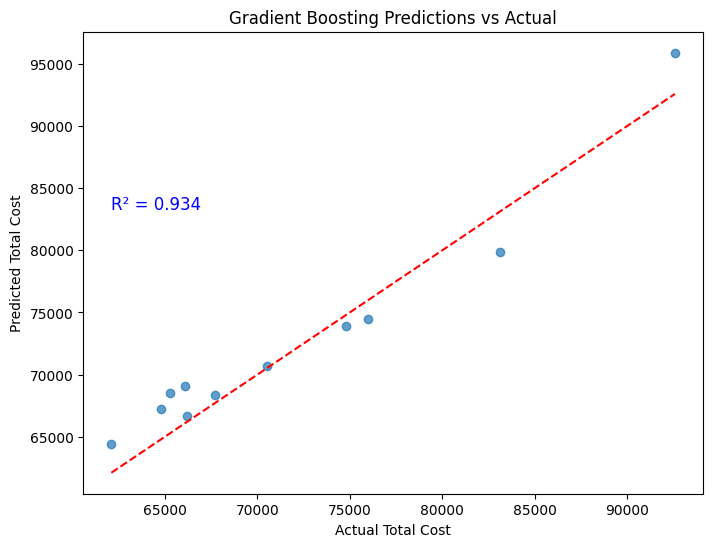

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Compute R²
r2 = r2_score(y_test, y_pred)

# Create scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # diagonal line: perfect prediction

# Add R² text on the plot
plt.text(x=y_test.min(), 
         y=y_test.max()*0.9,  # position near top-left
         s=f'R² = {r2:.3f}',  # 3 decimal places
         fontsize=12,
         color='blue')

plt.xlabel("Actual Total Cost")
plt.ylabel("Predicted Total Cost")
plt.title("Gradient Boosting Predictions vs Actual")
plt.show()